# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets

In [2]:
df = pd.read_csv("1776250375-P2-Healthcare Analytics for Doctor Visits.csv")

# Understanding Dataset

In [3]:
# top 5 rows

df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [4]:
# last 5 rows

df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [5]:
# Dataset Shape - number of rows (records) and columns (features)

print("No. of rows: ", df.shape[0])
print("No. of columns: ", df.shape[1])

No. of rows:  5190
No. of columns:  13


In [6]:
# Display column names and their data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [7]:
# Statistical summary of numerical variables

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,5190.0,2595.500000,1498.368279,1.00,1298.25,2595.50,3892.75,5190.00
visits,5190.0,0.301734,0.798134,0.00,0.00,0.00,0.00,9.00
age,5190.0,0.406385,0.204782,0.19,0.22,0.32,0.62,0.72
income,5190.0,0.583160,0.368907,0.00,0.25,0.55,0.90,1.50
illness,5190.0,1.431985,1.384152,0.00,0.00,1.00,2.00,5.00
reduced,5190.0,0.861850,2.887628,0.00,0.00,0.00,0.00,14.00
health,5190.0,1.217534,2.124266,0.00,0.00,0.00,2.00,12.00


In [8]:
# Summary of categorical variables

df.describe(include = "object")

,gender,private,freepoor,freerepat,nchronic,lchronic
count,5190,5190,5190,5190,5190,5190
unique,2,2,2,2,2,2
top,female,no,no,no,no,no
freq,2702,2892,4968,4099,3098,4585


In [9]:
# Number of unique values in each column

unique_summary = pd.DataFrame({
    'Column': df.columns,
    'Unique Values': df.nunique().values
})

unique_summary

,Column,Unique Values
0,Unnamed: 0,5190
1,visits,10
2,gender,2
3,age,12
4,income,14
5,illness,6
6,reduced,15
7,health,13
8,private,2
9,freepoor,2


In [10]:
# Display unique values of categorical variables

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


gender
['female' 'male']

private
['yes' 'no']

freepoor
['no' 'yes']

freerepat
['no' 'yes']

nchronic
['no' 'yes']

lchronic
['no' 'yes']


# Data Cleaning

In [11]:
# Check data types

df.dtypes

Unnamed: 0      int64
visits          int64
gender         object
age           float64
income        float64
illness         int64
reduced         int64
health          int64
private        object
freepoor       object
freerepat      object
nchronic       object
lchronic       object
dtype: object

In [12]:
# checking missing values

df.isnull().sum()

Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64

In [13]:
# Check duplicate records

d = df.duplicated().sum() 
print("No. of duplicate records:", d)

No. of duplicate records: 0


In [14]:
# Rename the ID column

df.rename(columns={"Unnamed: 0": "record_id"}, inplace=True)

df.head()

,record_id,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


# Univariate Analysis
Univariate analysis means analyzing one variable at a time.

The main purpose is to understand the distribution, frequency, central tendency, spread and unusual values of individual variables.

## A. Categorical Variables

gender
female    2702
male      2488
Name: count, dtype: int64


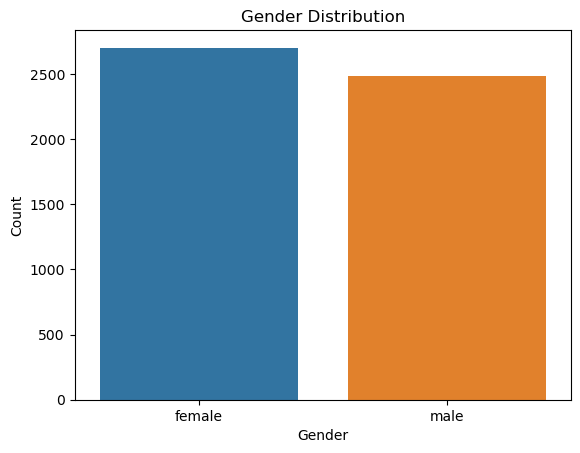

In [15]:
# Gender Distribution

x = df["gender"].value_counts()
print(x)

sns.countplot(data = df, x = "gender", hue = "gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

private
no     2892
yes    2298
Name: count, dtype: int64


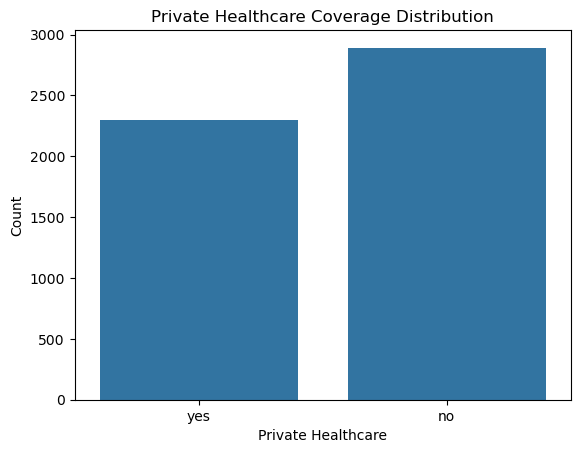

In [16]:
# Private healthcare - Shows whether the person has private healthcare or private health insurance coverage

x = df["private"].value_counts()
print(x)

sns.countplot(data = df, x = "private")

plt.title("Private Healthcare Coverage Distribution")
plt.xlabel("Private Healthcare")
plt.ylabel("Count")

plt.show()

freepoor
no     4968
yes     222
Name: count, dtype: int64


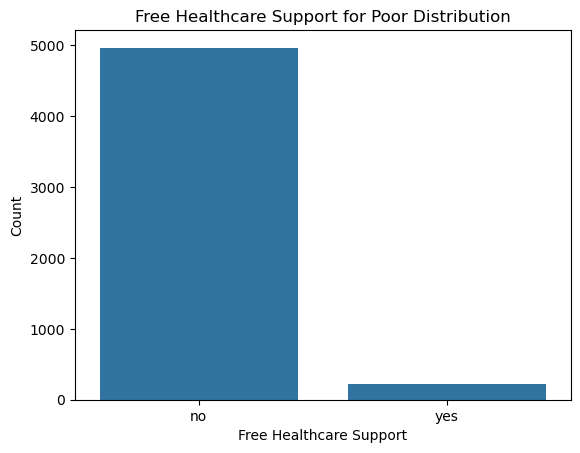

In [17]:
# freepoor - Shows whether the person receives free healthcare support based on financial need

x = df["freepoor"].value_counts()
print(x)

sns.countplot(data = df, x = "freepoor")

plt.title("Free Healthcare Support for Poor Distribution")
plt.xlabel("Free Healthcare Support")
plt.ylabel("Count")

plt.show()

freerepat
no     4099
yes    1091
Name: count, dtype: int64


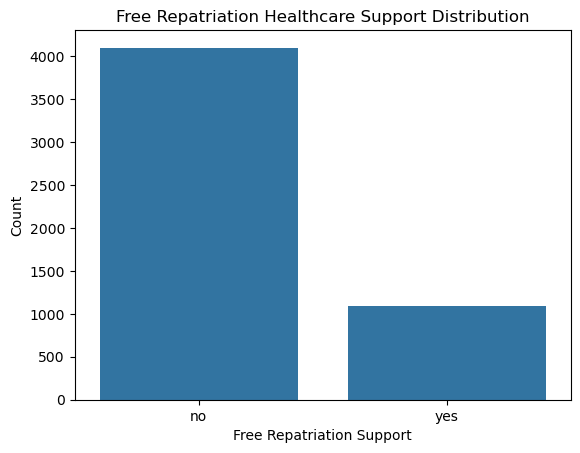

In [18]:
# freerepat - Shows whether the person receives healthcare through a special repatriation-related healthcare support program

x = df["freerepat"].value_counts()
print(x)

sns.countplot(data = df, x = "freerepat")

plt.title("Free Repatriation Healthcare Support Distribution")
plt.xlabel("Free Repatriation Support")
plt.ylabel("Count")

plt.show()

nchronic
no     3098
yes    2092
Name: count, dtype: int64


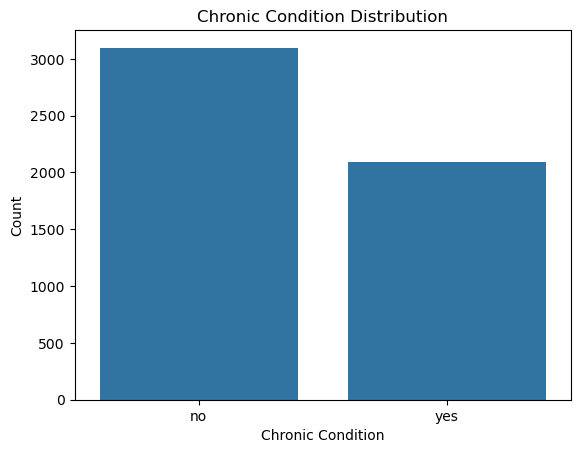

In [19]:
# Chronic condition - nchronic - Shows whether the person has a chronic health condition

x = df["nchronic"].value_counts()
print(x)

sns.countplot(data = df, x = "nchronic")

plt.title("Chronic Condition Distribution")
plt.xlabel("Chronic Condition")
plt.ylabel("Count")

plt.show()

lchronic
no     4585
yes     605
Name: count, dtype: int64


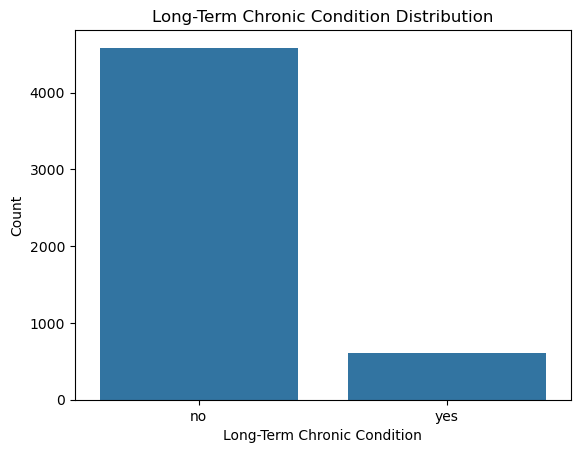

In [20]:
# Chronic condition - lchronic - Shows whether the person has a long-term chronic health condition

x = df["lchronic"].value_counts()
print(x)

sns.countplot(data = df, x = "lchronic")

plt.title("Long-Term Chronic Condition Distribution")
plt.xlabel("Long-Term Chronic Condition")
plt.ylabel("Count")

plt.show()

## B. Numerical Variables 

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
record_id,5190.0,2595.500000,1498.368279,1.00,1298.25,2595.50,3892.75,5190.00
visits,5190.0,0.301734,0.798134,0.00,0.00,0.00,0.00,9.00
age,5190.0,0.406385,0.204782,0.19,0.22,0.32,0.62,0.72
income,5190.0,0.583160,0.368907,0.00,0.25,0.55,0.90,1.50
illness,5190.0,1.431985,1.384152,0.00,0.00,1.00,2.00,5.00
reduced,5190.0,0.861850,2.887628,0.00,0.00,0.00,0.00,14.00
health,5190.0,1.217534,2.124266,0.00,0.00,0.00,2.00,12.00


visits
0    4141
1     782
2     174
3      30
4      24
5       9
6      12
7      12
8       5
9       1
Name: count, dtype: int64


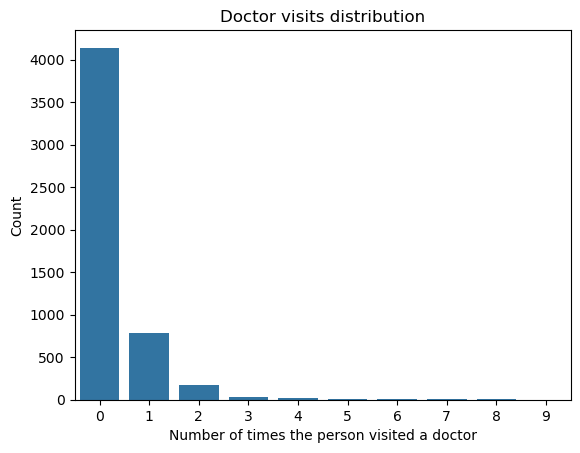

In [22]:
# Number of times the person visited a doctor during the period covered by the dataset

x = df["visits"].value_counts().sort_index()
print(x)

sns.countplot(data = df, x = "visits")

plt.title("Doctor visits distribution")
plt.xlabel("Number of times the person visited a doctor")
plt.ylabel("Count")

plt.show()

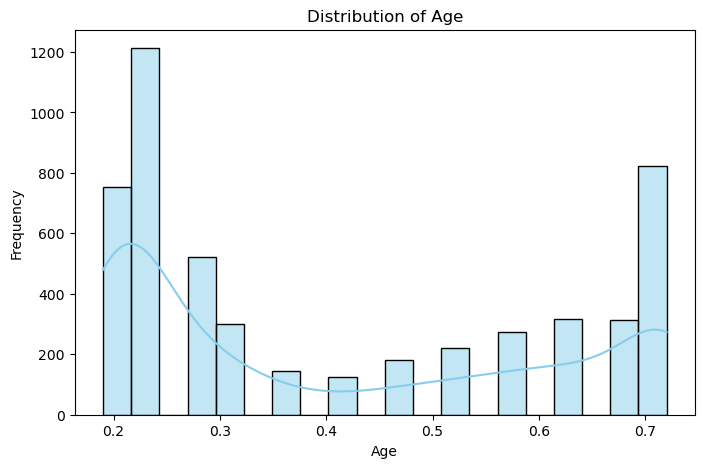

In [23]:
# Age Distribution

plt.figure(figsize=(8, 5))

sns.histplot(df['age'], bins = 20, kde = True, color='skyblue')

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

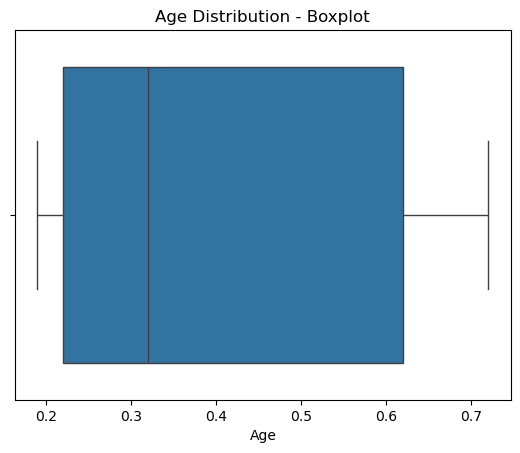

In [24]:
sns.boxplot(data = df, x = "age")

plt.title("Age Distribution - Boxplot")
plt.xlabel("Age")

plt.show()

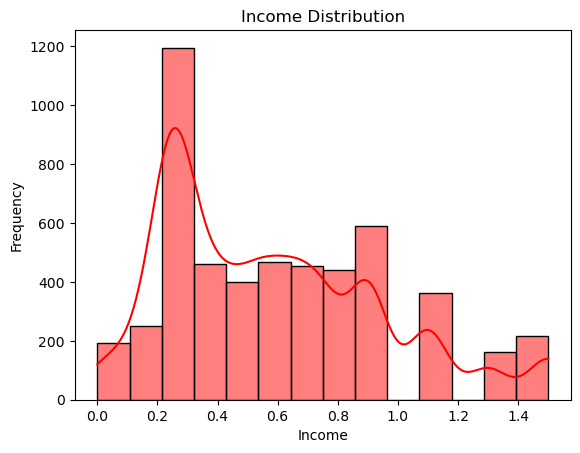

In [25]:
# Income Distribution 

sns.histplot(data = df, x = "income", bins = 14, kde = True, color = "red")

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

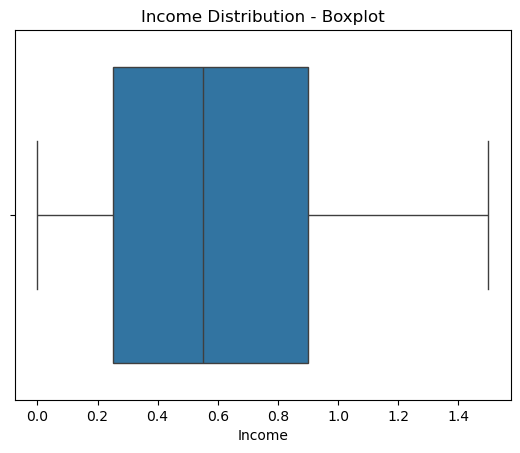

In [26]:
sns.boxplot(x = df["income"])

plt.title("Income Distribution - Boxplot")
plt.xlabel("Income")

plt.show()

illness
0    1554
1    1638
2     946
3     542
4     274
5     236
Name: count, dtype: int64


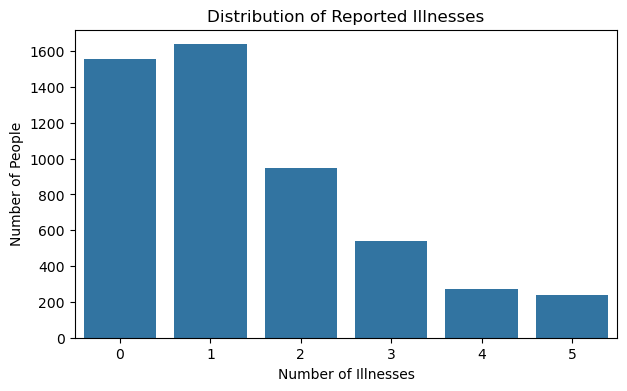

In [27]:
# Illness Distribution - Number of illnesses or health problems reported by the person

x = df["illness"].value_counts().sort_index()
print(x)

plt.figure(figsize=(7, 4))

illness = sns.countplot(data = df, x = "illness")

plt.title("Distribution of Reported Illnesses")
plt.xlabel("Number of Illnesses")
plt.ylabel("Number of People")

plt.show()

reduced
0     4454
1      177
2      108
3       74
4       45
5       40
6       17
7       38
8       17
9        7
10      12
11       2
12       6
13       5
14     188
Name: count, dtype: int64


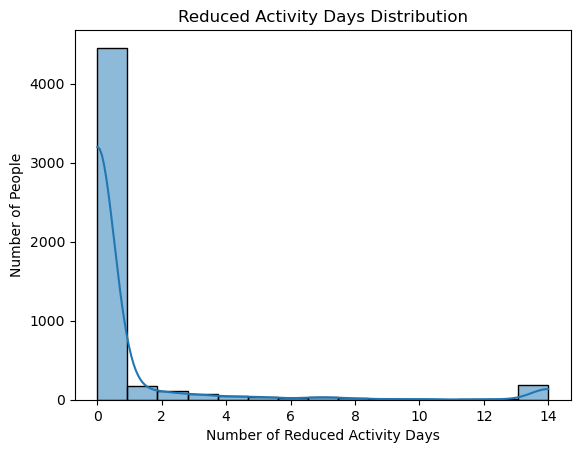

In [28]:
# Reduced Activity Days Distribution - Number of days the person's normal activities were reduced or affected because of health problems

x = df["reduced"].value_counts().sort_index()
print(x)

sns.histplot(data = df, x = "reduced", bins = 15, kde = True)

plt.title("Reduced Activity Days Distribution")
plt.xlabel("Number of Reduced Activity Days")
plt.ylabel("Number of People")

plt.show()

# Bivariate Analysis

Bivariate analysis means analyzing two variables together to understand whether there is a relationship, difference or pattern between them

        count      mean
gender                 
female   2702  0.361954
male     2488  0.236334


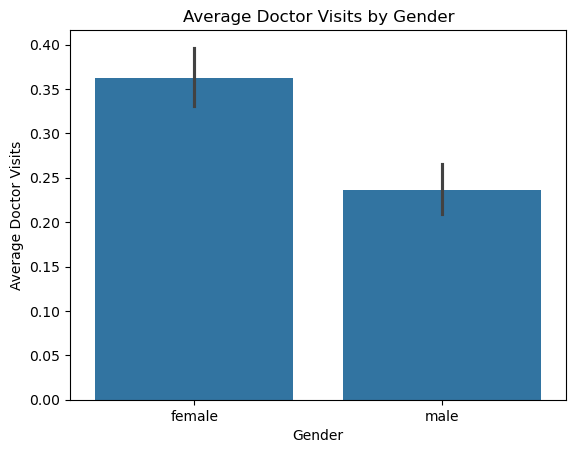

In [29]:
# Gender vs Doctor Visits

x = df.groupby("gender")["visits"].agg(["count","mean"])
print(x)

sns.barplot(data = df, 
            x = "gender", y = "visits", 
            estimator = "mean")

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Doctor Visits")

plt.show()

         count      mean
private                 
no        2892  0.307400
yes       2298  0.294604


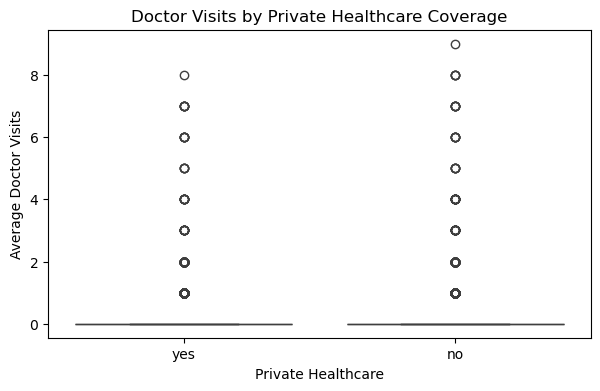

In [30]:
# Private healthcare vs average Doctor visits - compare average doctor visits between the two groups

x = df.groupby("private")["visits"].agg(["count", "mean"])
print(x)

plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="private", y="visits")

plt.title("Doctor Visits by Private Healthcare Coverage")
plt.xlabel("Private Healthcare")
plt.ylabel("Average Doctor Visits")

plt.show()


          count      mean
freepoor                 
no         4968  0.308172
yes         222  0.157658


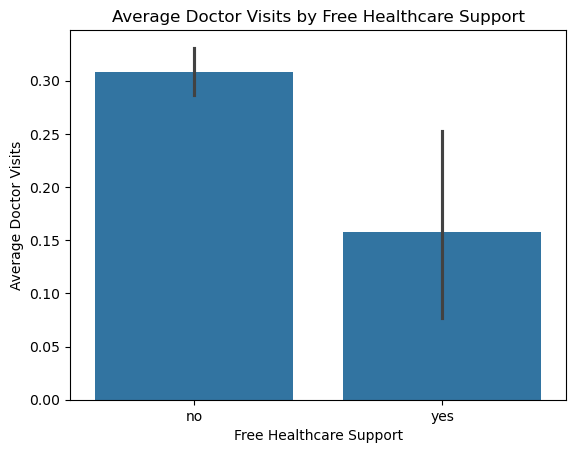

In [31]:
# Free healthcare support vs average Doctor visits

x = df.groupby("freepoor")["visits"].agg(["count", "mean"])
print(x)

sns.barplot(data = df,
            x = "freepoor", y = "visits",
            estimator="mean")

plt.title("Average Doctor Visits by Free Healthcare Support")
plt.xlabel("Free Healthcare Support")
plt.ylabel("Average Doctor Visits")

plt.show()

          count      mean
nchronic                 
no         3098  0.272111
yes        2092  0.345602


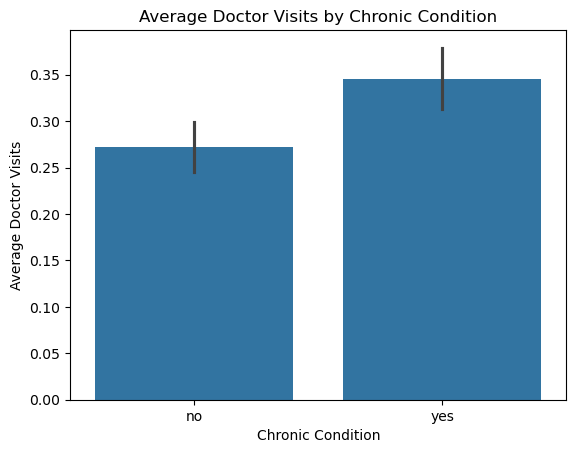

In [32]:
# Chronic condition - nchronic vs average Doctor visits

x = df.groupby("nchronic")["visits"].agg(["count", "mean"])
print(x)

sns.barplot(data = df,
            x = "nchronic", y = "visits",
            estimator = "mean")

plt.title("Average Doctor Visits by Chronic Condition")
plt.xlabel("Chronic Condition")
plt.ylabel("Average Doctor Visits")

plt.show()

Patients with a chronic condition have a higher average number of doctor visits than those without a chronic condition.

          count      mean
lchronic                 
no         4585  0.261941
yes         605  0.603306


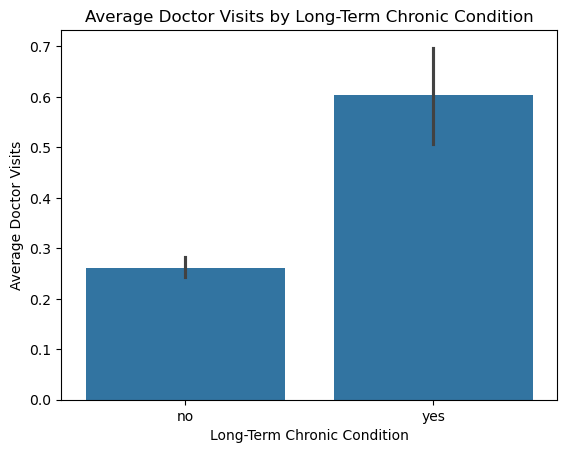

In [33]:
# Long-Term Chronic Condition vs average Doctor Visits

x = df.groupby("lchronic")["visits"].agg(["count", "mean"])
print(x)

sns.barplot(data = df,    
            x = "lchronic", y = "visits",
            estimator = "mean")

plt.title("Average Doctor Visits by Long-Term Chronic Condition")
plt.xlabel("Long-Term Chronic Condition")
plt.ylabel("Average Doctor Visits")

plt.show()

Participants with a long-term chronic condition have higher average number of doctor visits than participants without one.

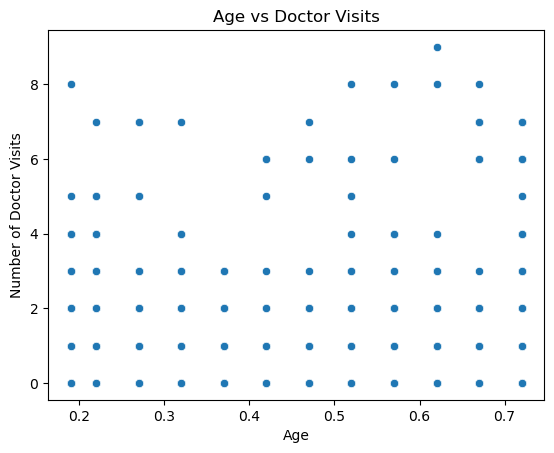

In [34]:
# Age vs Doctor Visits

sns.scatterplot(data = df, x = "age", y = "visits")

plt.title("Age vs Doctor Visits")
plt.xlabel("Age")
plt.ylabel("Number of Doctor Visits")

plt.show()

In [35]:
df["age"].corr(df["visits"])

np.float64(0.12453676134371812)

The age variable has a weak positive association with doctor visits in this dataset.

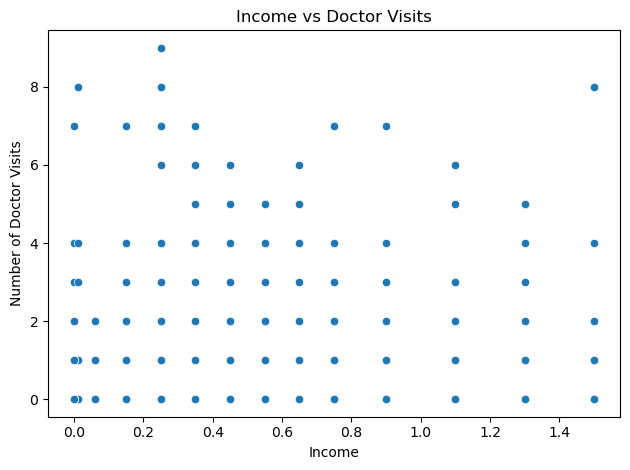

In [36]:
# Income vs Doctor Visits

sns.scatterplot(data=df, x="income", y="visits")

plt.title("Income vs Doctor Visits")
plt.xlabel("Income")
plt.ylabel("Number of Doctor Visits")

plt.tight_layout()
plt.show()

In [37]:
df["income"].corr(df["visits"])

np.float64(-0.07683982934758862)

Income has a negative relationship with doctor visits in this dataset. 

         count      mean
illness                 
0         1554  0.078507
1         1638  0.295482
2          946  0.403805
3          542  0.420664
4          274  0.576642
5          236  0.813559


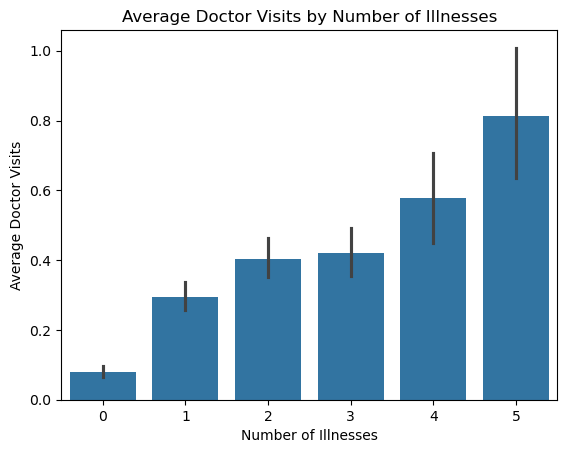

In [38]:
# Illness vs average Doctor visits

x = df.groupby("illness")["visits"].agg(["count", "mean"])
print(x)

sns.barplot(data = df, 
            x = "illness", y = "visits",
            estimator = "mean")

plt.title("Average Doctor Visits by Number of Illnesses")
plt.xlabel("Number of Illnesses")
plt.ylabel("Average Doctor Visits")

plt.show()

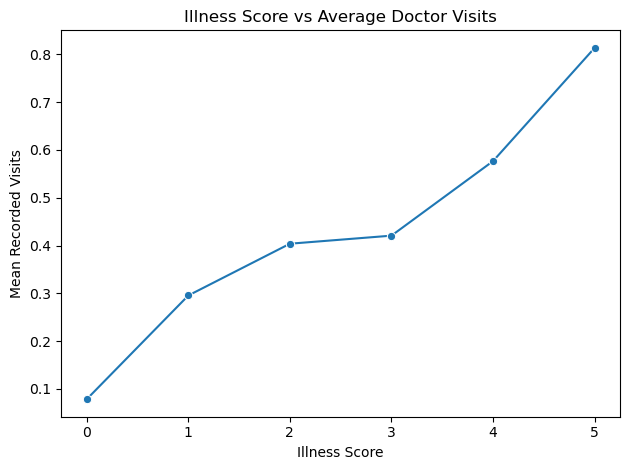

In [39]:
# Average Doctor Visits for each Illness Score

x = df.groupby("illness")["visits"].mean().reset_index()

sns.lineplot(data=x,
             x="illness", y="visits",
             marker="o")

plt.title("Illness Score vs Average Doctor Visits")
plt.xlabel("Illness Score")
plt.ylabel("Mean Recorded Visits")

plt.tight_layout()
plt.show()

Average doctor visits generally increase as the number of reported illnesses increases. Patients with five illnesses have the highest average number of visits in this dataset.

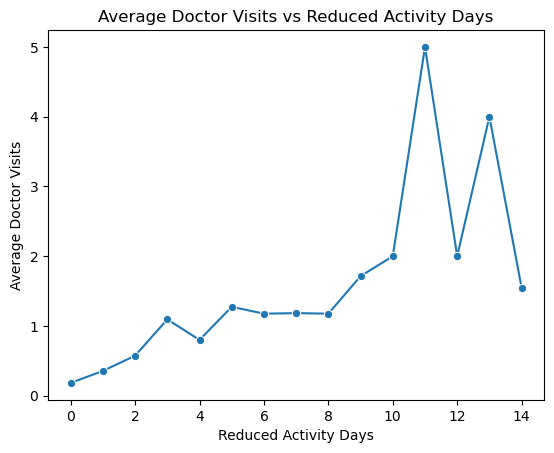

In [40]:
# Reduced activity Days vs average Doctor visits

reduced_visits = df.groupby("reduced")["visits"].mean().reset_index()

sns.lineplot(data = reduced_visits,
             x = "reduced", y = "visits",
             marker = "o")

plt.title("Average Doctor Visits vs Reduced Activity Days")
plt.xlabel("Reduced Activity Days")
plt.ylabel("Average Doctor Visits")

plt.show()

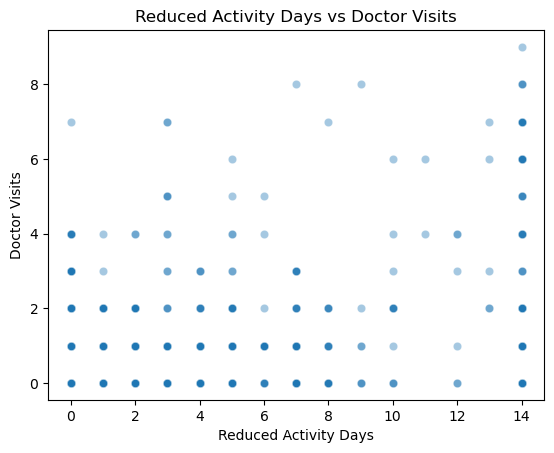

In [41]:
# Reduced activity Days vs average Doctor visits

sns.scatterplot(data=df, 
                x="reduced", y="visits",
                alpha=0.4)

plt.title("Reduced Activity Days vs Doctor Visits")
plt.xlabel("Reduced Activity Days")
plt.ylabel("Doctor Visits")

plt.show()

In [42]:
df["reduced"].corr(df["visits"])

np.float64(0.41895443516049913)

Reduced activity days show a positive relationship with doctor visits. As the number of reduced-activity days increases, doctor visits generally tend to increase.

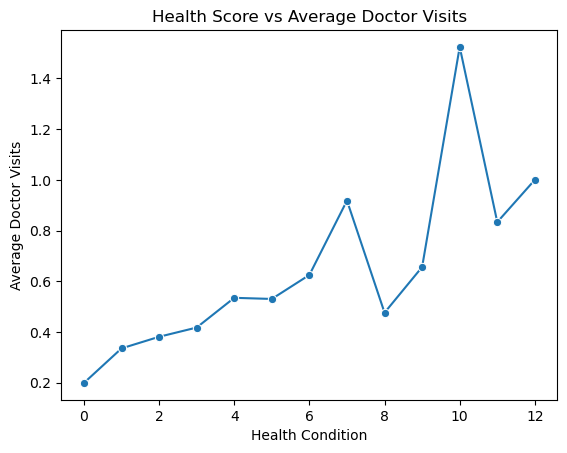

In [43]:
# Health vs average Doctor visits

health_visits = df.groupby("health")["visits"].mean().reset_index()

sns.lineplot(data=health_visits,
             x="health", y="visits",
             marker="o")

plt.title("Health Score vs Average Doctor Visits")
plt.xlabel("Health Condition")
plt.ylabel("Average Doctor Visits")

plt.show()

In [44]:
df["health"].corr(df["visits"])

np.float64(0.1932715570517201)

Health condition shows a positive association with doctor visits, although the relationship is weaker than the relationship observed for reduced activity days.
    

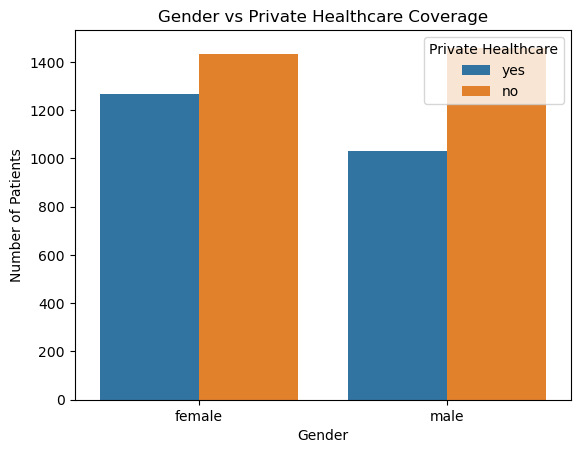

In [45]:
# Gender vs Private Healthcare Support

sns.countplot(data=df, x="gender", hue="private")

plt.title("Gender vs Private Healthcare Coverage")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.legend(title="Private Healthcare")
plt.show()

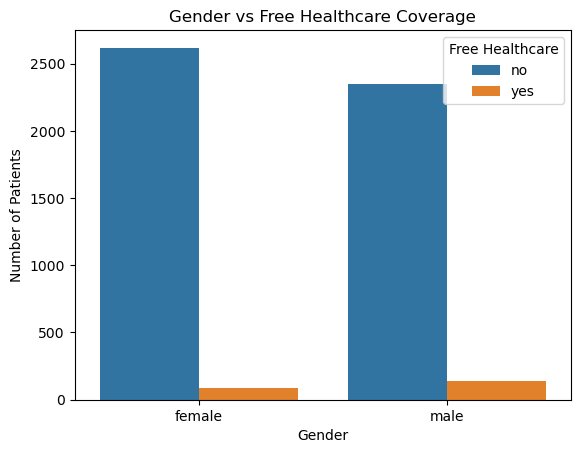

In [46]:
# Gender vs Free Healthcare Support

sns.countplot(data=df, x="gender", hue="freepoor")

plt.title("Gender vs Free Healthcare Coverage")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.legend(title="Free Healthcare")
plt.show()

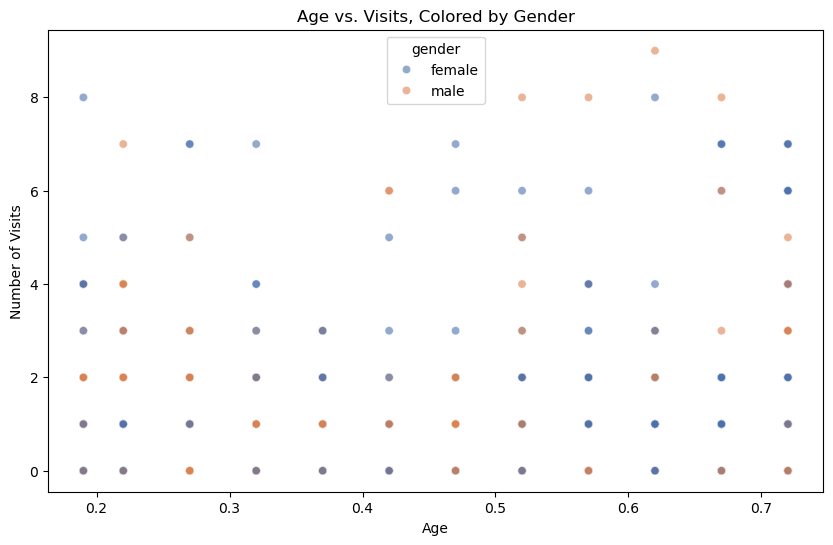

In [47]:
# Multivariate Analysis: Age, Visits, and Gender

plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='visits', hue='gender', data=df, palette='deep', alpha=0.6)
plt.title('Age vs. Visits, Colored by Gender')
plt.xlabel('Age')
plt.ylabel('Number of Visits')
plt.show()

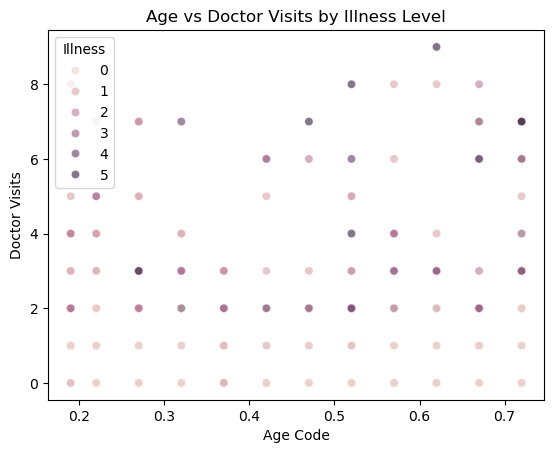

In [48]:
# Age vs Doctor Visits by Illness Level
sns.scatterplot(data=df, x="age", y="visits", hue="illness", alpha=0.6)

plt.title("Age vs Doctor Visits by Illness Level")
plt.xlabel("Age Code")
plt.ylabel("Doctor Visits")
plt.legend(title="Illness")

plt.show()